# Training

In [ ]:
from ddsp import DDSP, AudioDataset
from ddsp.callbacks import BetaWarmupEpochCallback
from ddsp.synths import NoiseBandSynth, SineSynth
from ddsp.utils import find_checkpoint

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning import Trainer

from IPython.display import Audio, display

from torch.utils.data import DataLoader, Subset, random_split

import torch
import umap

torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')


import os

experiment_root = '/home/btadeusz/code/ddsp_vae/experiments/wasserstein_loss/'
training_root = os.path.join(experiment_root, 'training')

In [ ]:
# Dataset parameters
chunk_duration = 2.0
sampling_rate = 16000
n_signal = chunk_duration * sampling_rate
batch_size = 16

# Model parameters
latent_size = num_params = 128
n_sines = 1

# Training parameters
# warmup_start = 300
# warmup_end = 500
# beta = 1.0
max_epochs = 5000
learning_rate = 1e-4


In [ ]:
def get_dataset_split(dataset_path, validation_split=0.2):
  """
  Splits the dataset into training and validation sets.
  """
  generator = torch.Generator(device='cuda')

  dataset_A = AudioDataset(dataset_path=dataset_path, n_signal=n_signal)
  total_len = len(dataset_A)

  val_len = int(validation_split * total_len)  # 20% for validation
  indices = torch.randperm(total_len, generator=generator)

  val_indices = indices[:val_len]
  train_indices = indices[val_len:]

  train_set = Subset(dataset_A, train_indices)
  val_set = Subset(dataset_A, val_indices)

  train_loader = DataLoader(train_set, batch_size, shuffle=True, num_workers=0, generator=generator)
  val_loader = DataLoader(val_set, batch_size, shuffle=False, num_workers=0, generator=generator)

  return train_loader, val_loader

def examine_model(model, val_loader):
  """
  Examines the trained model by displaying original and autoencoded audio samples,
  as well as reporting on the loss.
  """
  model = model.cuda()
  model.eval()
  with torch.no_grad():
    x_audio = next(iter(val_loader))
    x_audio = x_audio.to('cuda')

    # Forward pass through the model
    y_audio = model(x_audio).squeeze(1)

    print(x_audio.shape, y_audio.shape)

    # Display original and reconstructed audio
    for j in range(x_audio.shape[0]):
      print(f"Sample {j + 1}:")
      x_audio_j = x_audio[j].cpu()
      y_audio_j = y_audio[j].cpu()

      display(Audio(x_audio_j.numpy(), rate=sampling_rate))
      display(Audio(y_audio_j.numpy(), rate=sampling_rate))


In [ ]:
sines = SineSynth.to_config(fs=sampling_rate, n_sines=n_sines)

ckpt = os.path.join(training_root, 'last.ckpt')

# ddsp = DDSP.load_from_checkpoint(ckpt, learning_rate=1e-5, plateau_patience=1000).to('cuda')
ddsp = DDSP(
  synth_configs=[sines],
  fs=sampling_rate,
  latent_size=latent_size,
  num_params=num_params,
  learning_rate=learning_rate,
  perceptual_loss_weight=0,
  plateau_patience=200,
).to('cuda')

best_checkpoint_callback = ModelCheckpoint(
  filename='best',
  monitor='val_loss',
  mode='min',
  save_top_k=1,
  save_last=True,
  dirpath=training_root,
)

trainer = Trainer(
  callbacks = [best_checkpoint_callback],
  max_epochs=max_epochs,
  accelerator='cuda',
  precision=16
)


train_loader, val_loader = get_dataset_split('/mnt/mariadata/datasets/syntex/am_and_chirps/BasicSines/audio')
trainer.fit(
    model=ddsp,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    # ckpt_path=ckpt
)

In [ ]:
examine_model(ddsp, val_loader)

# Implementing the loss

## Generate audio and display spectrograms

In [ ]:
import torch
from torch import nn
import numpy as np
import math
from IPython.display import Audio, display

import matplotlib.pyplot as plt
import seaborn as sns


fs = 8000
dur = 2 # seconds
n_samples = fs*dur
f1 = 2000
f2 = 1000
f3 = 100

x = torch.sin(torch.arange(n_samples)/fs*f1*2*np.pi)
y = torch.sin(torch.arange(n_samples)/fs*f1*2*np.pi)
# y += 0.3*torch.sin(torch.arange(n_samples)/fs*f3*2*np.pi)
y += 0.5*torch.randn(n_samples)

win_size = 256

display(Audio(x.detach().numpy(), rate=fs))

window = torch.hann_window(win_size)
X = torch.stft(x, n_fft=win_size, window=window, return_complex=True)
Y = torch.stft(y, n_fft=win_size, window=window, return_complex=True)

X_mag = torch.log(X.abs())
Y_mag = torch.log(Y.abs())
X = X / (X.sum() + 1e-8)
Y = Y / (Y.sum() + 1e-8)

F, T = X_mag.shape

tlabels = np.linspace(0, dur, T)
flabels = np.linspace(0, fs//2, F)

sns.set_theme()

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].pcolormesh(tlabels, flabels, X_mag, shading='auto', cmap='plasma')
axs[1].pcolormesh(tlabels, flabels, Y_mag, shading='auto', cmap='plasma')
fig.tight_layout()

plt.show()


## Calculate the wasserstein distance

In [3]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as func
from ot import wasserstein_1d
import scipy

torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')

win_size=2048
hop_size=512
eps=1e-8
n_projections=100
k=1e6

def stft(x: torch.Tensor) -> torch.Tensor:
    """
    Compute the Short-Time Fourier Transform (STFT) of the input signal.

    Args:
      - x: torch.Tensor, the input audio signal

    Returns:
      - X: torch.Tensor, the magnitude spectrum of the STFT
    """
    # window = torch.hann_window(win_size)
    window = scipy.signal.windows.flattop(win_size, sym=False)  # sym=False for FFT use
    window = torch.from_numpy(window).to(device='cuda', dtype=torch.float32)
    x_stft = torch.stft(x, n_fft=win_size, hop_length=hop_size, window=window, return_complex=True)
    x_mag = torch.sqrt(torch.clamp(x_stft.real**2 + x_stft.imag**2, min=eps))
    x_mag = torch.log(x_mag)
    return x_mag


def wasserstein_loss_pot(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Compute the Sliced Wasserstein loss between two audio signals.

    Args:
      - x: torch.Tensor[B, N], the first audio signal
      - y: torch.Tensor[B, N], the second audio signal

    Returns:
      - loss: torch.Tensor, the computed Sliced Wasserstein loss
    """
    # Ensure the input tensors are the same shape
    if x.shape != y.shape:
      raise ValueError("Input tensors must have the same shape.")

    X_mag = stft(x).permute(1, 0)  # shape: [T, F]
    Y_mag = stft(y).permute(1, 0)  # shape: [T, F]

    # TODO: Make sure that this is necessary & correct
    # X_mag = X_mag / (X_mag.sum() + eps)
    # Y_mag = Y_mag / (Y_mag.sum() + eps)
    X_mag = torch.softmax(X_mag.flatten(), dim=0).reshape(X_mag.shape)
    Y_mag = torch.softmax(Y_mag.flatten(), dim=0).reshape(Y_mag.shape)

    T, F = X_mag.shape

    time_bins = torch.linspace(0, T-1, T)
    freq_bins = torch.linspace(0, F-1, F)
    t_coords, f_coords = torch.meshgrid([time_bins, freq_bins], indexing='ij')

    thetas = torch.arange(0, n_projections) * 2 * torch.pi / n_projections
    diffs = []
    for theta in thetas:
      projected_coords = t_coords*torch.cos(theta)*math.sqrt(k) + f_coords*torch.sin(theta)
      coords_vec = projected_coords.flatten()
      X_vec = X_mag.flatten()
      Y_vec = Y_mag.flatten()

      diff = wasserstein_1d(coords_vec, coords_vec, X_vec, Y_vec, p=2, require_sort=True)
      diffs.append(diff)

    loss = torch.vstack(diffs).sum()/len(diffs)
    return loss


def wasserstein_loss_manual(x, y):
  X_mag = stft(x).permute(1, 0)  # shape: [T, F]
  Y_mag = stft(y).permute(1, 0)  # shape: [T, F]

  # X_mag = X_mag / (X_mag.sum() + eps)
  # Y_mag = Y_mag / (Y_mag.sum() + eps)
  X_mag = torch.softmax(X_mag.flatten(), dim=0).reshape(X_mag.shape)
  Y_mag = torch.softmax(Y_mag.flatten(), dim=0).reshape(Y_mag.shape)

  T, F = X_mag.shape

  freq_bins = torch.linspace(0, F-1, F)
  time_bins = torch.linspace(0, T-1, T)

  t_coords, f_coords = torch.meshgrid([time_bins, freq_bins], indexing='ij') # shape: [T, F]

  thetas = torch.linspace(0, 2*math.pi, n_projections+1)[:-1]
  diffs = []
  for theta in thetas:
    coords = torch.cos(theta) * math.sqrt(k) * t_coords  + torch.sin(theta) * f_coords

    # Flatten everything
    coords = coords.flatten()
    X_mag = X_mag.flatten()
    Y_mag = Y_mag.flatten()

    # Sort
    sorted_idx = torch.argsort(coords)

    # coords_sorted = coords[sorted_idx]
    X_mag_sorted = X_mag[sorted_idx]
    Y_mag_sorted = Y_mag[sorted_idx]

    # cumulative density functions
    x_cdf = torch.cumsum(X_mag_sorted, 0)
    y_cdf = torch.cumsum(Y_mag_sorted, 0)

    diff = torch.pow(x_cdf - y_cdf, 2).sum()
    diffs.append(diff)

  return torch.stack(diffs).sum()


def project_sort(x, proj):
  return torch.einsum('fn,fp->pn', x, proj).sort()[0]

def wasserstein_loss_random(x, y):
  X_mag = stft(x)  # shape: [F, T]
  Y_mag = stft(y)  # shape: [F, T]

  # TODO: Make sure that this is necessary & correct
  # X_mag = X_mag / (X_mag.sum() + eps)
  # Y_mag = Y_mag / (Y_mag.sum() + eps)
  X_mag = torch.softmax(X_mag.flatten(), dim=0).reshape(X_mag.shape)
  Y_mag = torch.softmax(Y_mag.flatten(), dim=0).reshape(Y_mag.shape)

  F, T = X_mag.shape

  projs = func.normalize(torch.randn(F, n_projections), dim=0)
  source_proj = project_sort(X_mag, projs)
  target_proj = project_sort(Y_mag, projs)
  # target_interp = F.interpolate(target_proj, n, mode='nearest')
  return (source_proj-target_proj).square().sum()


/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [ ]:
from auraloss.freq import MultiResolutionSTFTLoss
from ddsp.losses import SlicedWassersteinLoss
from time import time

sample_rate=44100
dur = 2 # seconds
n_samples = sample_rate*dur

fft_sizes=np.array([1024, 512, 256, 128, 64])
mss = MultiResolutionSTFTLoss(fft_sizes=fft_sizes, hop_sizes=fft_sizes//2, win_lengths=fft_sizes, w_lin_mag=1.0)
mss_loss = lambda x,y: mss(x.reshape(1,1,-1), y.reshape(1,1,-1))

wloss = SlicedWassersteinLoss(win_size=win_size, n_projections=n_projections, p=2, hop_size=hop_size, sampling_rate=sample_rate)
wasserstein_loss_batched = lambda x, y: wloss(x.unsqueeze(0), y.unsqueeze(0))

ot_losses = []
mss_losses = []

loss_functions = {
  # 'ot - manual': wasserstein_loss_manual,
  'ot - POT': wasserstein_loss_pot,
  'ot - batched': wasserstein_loss_batched,
  # 'ot - random': wasserstein_loss_random,
  'mss': mss_loss,
}

losses = {}
loss_calc_times = {}
for loss_fn_name in loss_functions.keys():
  losses[loss_fn_name] = []
  loss_calc_times[loss_fn_name] = []

base_freq = 10000
freq_shifts = torch.linspace(-8000, 8000, 201)[3:-3]
for freq_shift in freq_shifts:
  x = torch.sin(torch.arange(n_samples)/sample_rate * base_freq * 2 * torch.pi)
  y = torch.sin(torch.arange(n_samples)/sample_rate * (base_freq+freq_shift) * 2 * torch.pi)
  for loss_fn_desc, loss_fn in loss_functions.items():
    start_time = time()
    losses[loss_fn_desc].append(loss_fn(x, y))
    loss_calc_times[loss_fn_desc].append(time() - start_time)


for loss_fn_desc in loss_functions.keys():
  cur_losses = torch.vstack(losses[loss_fn_desc])
  cur_losses /= (cur_losses.max() + eps)
  cur_loss_avg_calc_time = np.array(loss_calc_times[loss_fn_desc]).mean() * 1000
  plt.plot(freq_shifts.cpu().detach()/1000, cur_losses.cpu().detach(), label=f'{loss_fn_desc}, avg time: {cur_loss_avg_calc_time:.2f}ms')


sns.set_style()
plt.ylabel('Normalized distance [0-1]')
plt.xlabel('Frequency shift [kHz]')
plt.legend()
plt.show()

KeyboardInterrupt: 

<!-- # Simple Training Scenario -->

Target frequency: 798.3242187649012


Training:   0%|          | 0/50000 [00:00<?, ?it/s]

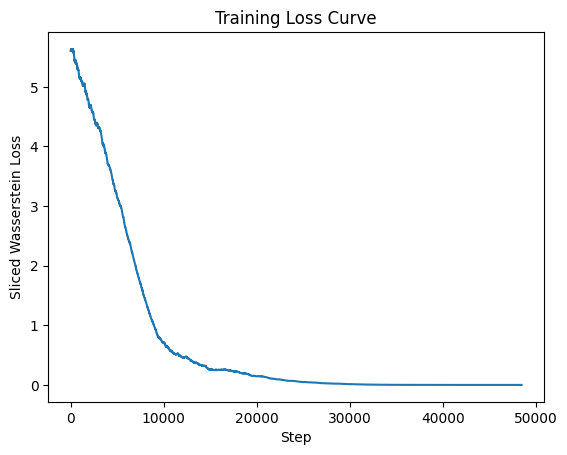

Fitted frequency: 799.43 Hz
Target frequency: 798.32 Hz


In [5]:
import torch
torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')

import numpy as np
from ddsp.losses import SlicedWassersteinLoss
from auraloss.freq import MultiResolutionSTFTLoss

from IPython.display import Audio, display
from tqdm.notebook import trange

# Configurable parameters
fs = 44100  # sample rate, can be changed
dur = 2.0   # seconds
n_samples = int(fs * dur)

# Loss
sw_loss = SlicedWassersteinLoss(sampling_rate=fs, n_projections=10, win_size=512, hop_size=256, p=2)
# mss_loss = MultiResolutionSTFTLoss()

# Training loop parameters
n_steps = 50000
learning_rate = 1e-3

# Randomize base frequency in [0, fs/2]
# target_freq = 6000
target_freq = torch.rand(1).item() * (fs / 2)

# Target sinusoid
t = torch.arange(n_samples, device='cuda') / fs
target = torch.cos(2 * np.pi * target_freq * t).to('cuda')

print("Target frequency:", target_freq)
display(Audio(target.cpu().numpy(), rate=fs))

a = torch.nn.Parameter(torch.randn(1, device='cuda'))
# a = torch.nn.Parameter(torch.Tensor([0.5]))

optimizer = torch.optim.Adam([a], lr=learning_rate)

losses = []
progress_bar = trange(n_steps, desc="Training", leave=True)
for step in progress_bar:
  optimizer.zero_grad()
  freq = torch.sigmoid(a) * (fs / 2)  # Ensure frequency is in [0, fs/2]
  synth = torch.cos(2 * np.pi * freq * t)

  loss = sw_loss(synth.unsqueeze(0), target.unsqueeze(0))
  if loss.item() < 1e-7:
    progress_bar.n = step + 1
    progress_bar.last_print_n = step + 1
    progress_bar.update(0)
    break

  loss.backward()
  optimizer.step()
  losses.append(loss.item())

  if step % 100 == 0 or step == n_steps - 1:
    progress_bar.set_postfix({"Loss": f"{loss.item():.6f}", "Freq": f"{freq.item():.2f}"})

import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Sliced Wasserstein Loss')
plt.title('Training Loss Curve')
plt.show()

print(f"Fitted frequency: {freq.item():.2f} Hz")
print(f"Target frequency: {target_freq:.2f} Hz")